# 3D FEM: Straight vs. Bent Didgeridoo

Companion to `fem2d_bent_didge.ipynb`. The 3D solver sweeps a circular
cross-section along the centerline curve to build a tetrahedral mesh, then
solves the 3D Helmholtz equation directly. Because the bend lives in the
actual geometry, the wavefront-shortcut effect that raises the bent
fundamental emerges naturally — no curvature correction or fitting parameter
is involved.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from didgelab.geo import Geo
from didgelab.sim.fem3d import FiniteElementsModeling3D, build_3d_mesh
from didgelab.sim.sim_interface import AcousticConstants

EXP_DIR = Path.cwd()
if not (EXP_DIR / 'geo.json').exists():
    EXP_DIR = (Path.cwd() / 'doc' / 'examples' / 'bent_shapes').resolve()
print('experiments dir:', EXP_DIR)


experiments dir: /Users/jannehring/workspaces/music/didgitaldoo/workspace/didge-lab/doc/examples/bent_shapes


## Load geometry and centerline

In [2]:
with open(EXP_DIR / 'geo.json') as f:
    geo_list = json.load(f)
geo = Geo(geo_list)
geo_arr = np.array(geo.geo)
bore_length_mm = float(geo_arr[-1, 0] - geo_arr[0, 0])
print(f'bore length: {bore_length_mm:.1f} mm, '
      f'mouth d: {geo_arr[0,1]:.1f} mm, bell d: {geo_arr[-1,1]:.1f} mm, '
      f'{len(geo_arr)} segments')

curve_df = pd.read_csv(EXP_DIR / 'curve.csv')
centerline_mm = curve_df[['Y', 'Z']].values * 1000.0
arc_mm = np.linalg.norm(np.diff(centerline_mm, axis=0), axis=1).sum()
print(f'centerline arc length: {arc_mm:.1f} mm  (bore: {bore_length_mm:.1f} mm)')


bore length: 1712.3 mm, mouth d: 32.0 mm, bell d: 90.7 mm, 36 segments
centerline arc length: 1700.9 mm  (bore: 1712.3 mm)


## Mesh parameters

The 3D mesh has `n_axial * (1 + (n_radial - 1) * n_circ)` nodes. Defaults
give ~1700 nodes and ~7k tetrahedra: spectrum sweep of ~100 frequencies in
~2-3 s. Push `n_axial` / `n_circ` up for accuracy (the shift converges from
above as the mesh refines).


In [3]:
N_AXIAL  = 80
N_RADIAL = 3
N_CIRC   = 10

# Drop the 180-degree loop near row 192 of curve.csv before sweeping the
# circular cross-section: a fold-back would self-intersect the bell volume.
CURVE_END_FRAC = 1.0

_n = len(centerline_mm)
_keep = max(2, int(round(_n * CURVE_END_FRAC)))
centerline_used = centerline_mm[:_keep]
print(f'using first {_keep}/{_n} curve points ({100*_keep/_n:.1f}%)')


using first 194/194 curve points (100.0%)


## Build straight and bent 3D meshes

In [4]:
mesh_str, pts_str, mouth_str, bell_str = build_3d_mesh(
    geo_arr, n_axial=N_AXIAL, n_radial=N_RADIAL, n_circ=N_CIRC,
    centerline=None,
)
mesh_bent, pts_bent, mouth_bent, bell_bent = build_3d_mesh(
    geo_arr, n_axial=N_AXIAL, n_radial=N_RADIAL, n_circ=N_CIRC,
    centerline=centerline_used,
)

n_disk = 1 + (N_RADIAL - 1) * N_CIRC
print(f'disk nodes per cross-section: {n_disk}')
print(f'straight: {pts_str.shape[0]} nodes, {mesh_str.t.shape[1]} tets')
print(f'bent    : {pts_bent.shape[0]} nodes, {mesh_bent.t.shape[1]} tets')


disk nodes per cross-section: 21
straight: 1680 nodes, 7110 tets
bent    : 1680 nodes, 7110 tets


## Visualise the bent bore

3D scatter of cross-section centers plus a wireframe of the bore surface
(the outer ring of each cross-section). The mouth is green, bell red.


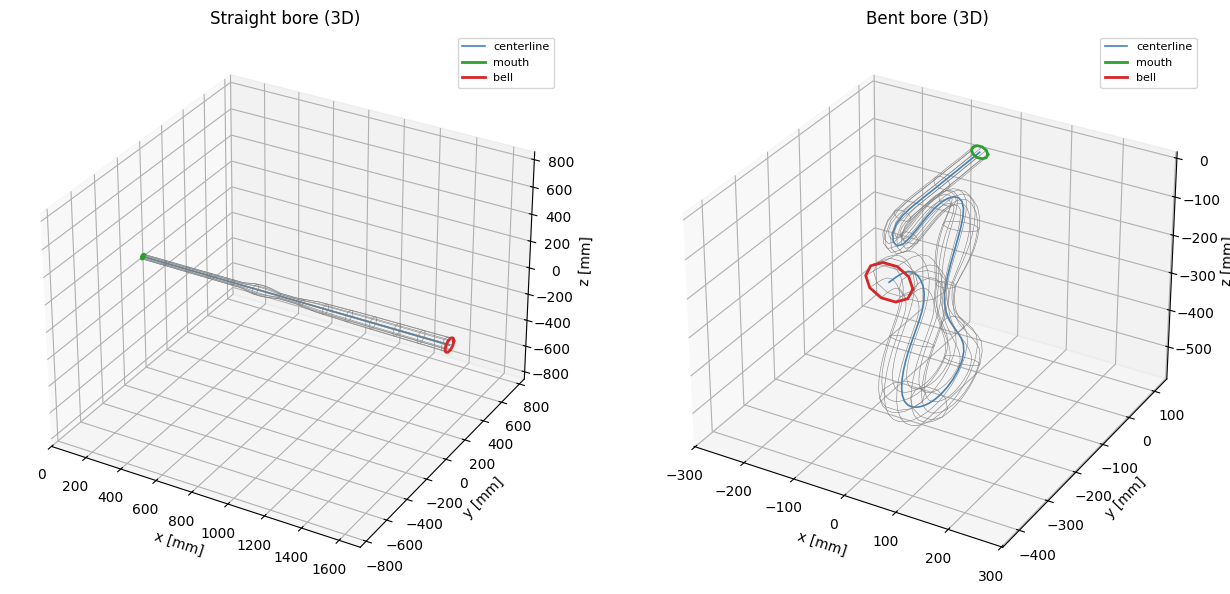

In [5]:
def _plot_bore_3d(ax, points, n_axial, n_radial, n_circ, title):
    nd = 1 + (n_radial - 1) * n_circ
    grid = points.reshape(n_axial, nd, 3)
    # Centerline (disk center node = index 0 in each disk)
    spine = grid[:, 0, :]
    ax.plot(spine[:, 0], spine[:, 1], spine[:, 2],
            color='steelblue', linewidth=1.2, label='centerline')

    # Outer ring (the last ring of disk nodes)
    outer = grid[:, 1 + (n_radial - 2) * n_circ:1 + (n_radial - 1) * n_circ, :]
    # Close the ring loop for plotting
    outer_closed = np.concatenate([outer, outer[:, :1, :]], axis=1)
    # Axial lines on the outer surface
    for k in range(n_circ):
        ax.plot(outer_closed[:, k, 0], outer_closed[:, k, 1], outer_closed[:, k, 2],
                color='gray', linewidth=0.4)
    # Circumferential rings every few stations
    step = max(1, n_axial // 12)
    for i in range(0, n_axial, step):
        ax.plot(outer_closed[i, :, 0], outer_closed[i, :, 1], outer_closed[i, :, 2],
                color='gray', linewidth=0.4)

    # Mouth and bell rings highlighted
    ax.plot(outer_closed[0, :, 0], outer_closed[0, :, 1], outer_closed[0, :, 2],
            color='tab:green', linewidth=2.0, label='mouth')
    ax.plot(outer_closed[-1, :, 0], outer_closed[-1, :, 1], outer_closed[-1, :, 2],
            color='tab:red', linewidth=2.0, label='bell')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]'); ax.set_zlabel('z [mm]')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    # Equal aspect (matplotlib 3D needs manual setup)
    extents = np.array([
        [points[:, d].min(), points[:, d].max()] for d in range(3)
    ])
    sz = (extents[:, 1] - extents[:, 0]).max() / 2.0
    mid = extents.mean(axis=1)
    for d, setter in zip(range(3),
                         (ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        setter(mid[d] - sz, mid[d] + sz)

fig = plt.figure(figsize=(13, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
_plot_bore_3d(ax1, pts_str, N_AXIAL, N_RADIAL, N_CIRC, 'Straight bore (3D)')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
_plot_bore_3d(ax2, pts_bent, N_AXIAL, N_RADIAL, N_CIRC, 'Bent bore (3D)')
plt.tight_layout()
plt.show()


## Run the 3D impedance sweep

In [6]:
# Dense sampling below 200 Hz so cent-level shifts on the fundamental and
# first overtones aren't lost to bin quantisation.
from didgelab import get_log_simulation_frequencies

freqs = get_log_simulation_frequencies()

constants = AcousticConstants()

sim_straight = FiniteElementsModeling3D(
    constants=constants, centerline=None,
    n_axial=N_AXIAL, n_radial=N_RADIAL, n_circ=N_CIRC,
)
sim_bent = FiniteElementsModeling3D(
    constants=constants, centerline=centerline_used,
    n_axial=N_AXIAL, n_radial=N_RADIAL, n_circ=N_CIRC,
)

imp_straight = sim_straight.get_impedance_spectrum(geo, freqs)
imp_bent = sim_bent.get_impedance_spectrum(geo, freqs)

f_s = freqs[int(np.argmax(imp_straight))]
f_b = freqs[int(np.argmax(imp_bent))]
print(f'peak (straight): {f_s:.3f} Hz')
print(f'peak (bent)    : {f_b:.3f} Hz  ({1200*np.log2(f_b/f_s):+.2f} cents)')


peak (straight): 75.595 Hz
peak (bent)    : 76.917 Hz  (+30.00 cents)


## Compare impedance spectra

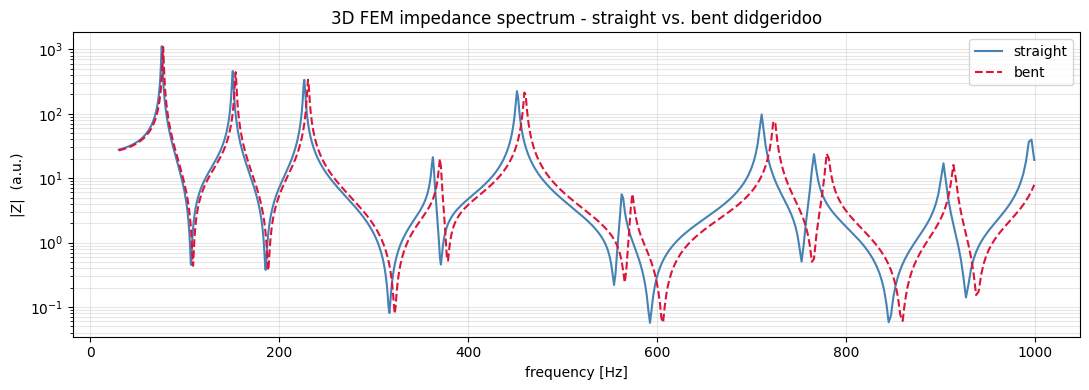

,straight_f,bent_f,cent_diff
0,75.60,76.92,30.0
1,150.75,153.83,35.0
2,226.53,230.49,30.0
3,362.72,370.13,35.0
4,451.75,459.65,30.0


In [7]:
from didgelab import cent_diff

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(freqs, imp_straight, label='straight', color='steelblue')
ax.plot(freqs, imp_bent, label='bent', color='crimson', linestyle='--')
ax.set_xlabel('frequency [Hz]')
ax.set_ylabel('|Z|  (a.u.)')
ax.set_yscale('log')
ax.set_title('3D FEM impedance spectrum - straight vs. bent didgeridoo')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

from scipy.signal import argrelmax
data = pd.DataFrame({
    'straight_f': freqs[argrelmax(imp_straight)][:5],
    'bent_f':     freqs[argrelmax(imp_bent)][:5],
})

data['cent_diff'] = [cent_diff(f_straight, f_bent) for f_straight, f_bent in zip(data.straight_f, data.bent_f)]
data.round(2)


## Notes

- The 3D solver sweeps a circular cross-section along the (possibly bent)
  centerline using a Bishop-frame parallel transport, so the cross-section
  stays orthogonal to the local tangent without spurious twisting.
- No `bent_shortcut` knob and no `curvature_alpha` parameter: the geometry
  itself produces the bent-tube pitch shift.
- The reported shift is sensitive to mesh resolution; it converges from
  above as you increase `N_AXIAL` / `N_CIRC`. Push them up if you need a
  high-accuracy answer for a particular bent didge.
- For very tight bends (curve self-intersections after the cross-section is
  swept), trim with `CURVE_END_FRAC` first; the sweep doesn't check for
  self-intersection.
